[]


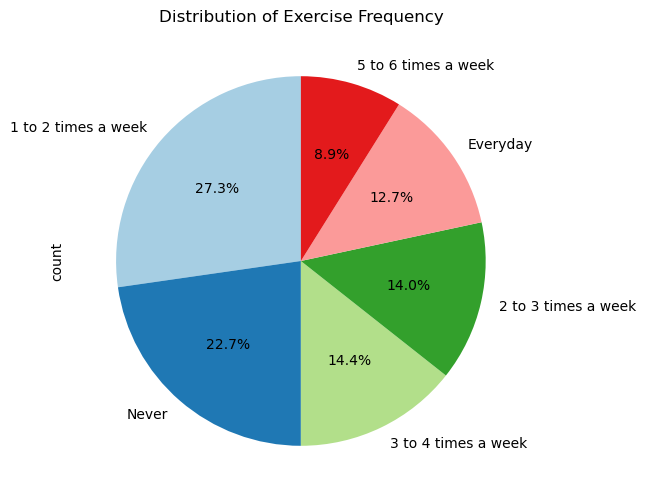

In [32]:
import pandas as pd

data = pd.read_csv('5_health-consultation-client.csv')
# print(data.info())
# print(data.columns)
data_cleaned = data.dropna()
data_cleaned.loc[:, 'Your age'] = pd.to_numeric(data_cleaned['Your age'], errors='coerce')
data_cleaned = data_cleaned.dropna(subset=['Your age'])
data_cleaned = data_cleaned[data_cleaned['Your age'] >= 0]
data_cleaned.loc[:, 'Your age'] = data_cleaned['Your age'].astype(int)
data_cleaned = data_cleaned.drop_duplicates()

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
data_cleaned['How do you describe your current level of fitness ?'] = label_encoder.fit_transform(data_cleaned['How do you describe your current level of fitness ?'])
print(data_cleaned['How do you describe your current level of fitness ?'].unique())

import matplotlib.pyplot as plt

data.columns = data.columns.str.strip()
data = data.dropna(subset=['How often do you exercise?'])
exercise_frequency_counts= data['How often do you exercise?'].value_counts()

plt.figure(figsize=(10, 6))
exercise_frequency_counts.plot.pie(autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('Distribution of Exercise Frequency')
plt.show()

from sklearn.model_selection import train_test_split

data_filled = data.apply(lambda x: x.fillna(x.mode()[0]))

train_data, test_data = train_test_split(data_filled, test_size=0.2, random_state=42)
data_filled.to_csv('5_health-consultation-client_cleaned.csv', index=False)